# Vietnam — F-Score grid study: k ∈ {20, 25, 30} × N ∈ {1000, 2000, 5000}

The Vietnam share of the grid: basket sizes × random-sample sizes × three
markets, 27 cells in all. The nine Vietnam cells run in this one notebook;
each writes `results/grid/vietnam_k{k}_mc{N}_*.csv` and its four figures
exactly as before, so the per-cell outputs are unchanged.

Signals and prices come from the team's own preprocessing pipeline (`src/fscore_vietnam`), which crawls FireAnt, CafeF and TCBS into `fscore.db`, reconciles the three, applies accounting checks and writes a per-firm-year panel; `run_grid_export.ipynb` there ships the score panel and the dividend-adjusted price panel this notebook reads. Those flags are used **as shipped** — this repository does not re-score Vietnam, in this notebook or in the main study, so there is one Vietnamese F-Score and one place it is defined. A recomputation from rebuilt statement lines did once run here and agreed on all 9,482 scored firm-years and all nine flags; it was removed for producing a second copy of a number it never changed. One gate has no counterpart in the US or Japan: the Vietnamese panel is pre-screened for tradability by June turnover, which removes about a third of the scoreable firm-years before this notebook sees them (section 0).

Formations are July 1 of **2012–2024** (13 chained holding years, each a full
twelve months) using score year T−1 — one conservative timing rule for every
market, over identical calendar time so the three are comparable. July 2024 is
the last formation whose complete year finishes inside the sample. Covariances
are estimated on 36 months of daily returns ending the day before formation.

Two universe caveats differ from the developed pair. Survivorship
is **partial rather than total**: 125 of the panel's 1,371 tickers
stop printing before 2026, spread across 2012–2025, so lines that
died inside the sample are present — but names the vendor no longer
resolves at all leave no trace to count, so the residual is
unquantified. And B/M coverage is **complete by construction** (the
pipeline requires it before export), so `value_fallback` is
false in every formation and the value control here is a real
30-name high-B/M basket in every year — unlike Japan's.

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW and
plain universe minimum-variance controls; a dollar-neutral long-short book (long top-k scores, short bottom-k, charged
both legs' trading costs plus a stock-borrow fee), run here as a
hypothetical — see below; denoised (not detoned) GMV; primary
measure fixed in advance = the GROSS Sharpe ratio (rf = 0), with turnover and
net-of-cost figures reported separately; and the synergy test
D = Sharpe(GMV) − Sharpe(EW) computed per basket. All figures are saved at
dpi = 300.

**On `fscore_LS` in Vietnam — a decomposition, not a portfolio.** Short
selling of ordinary shares is not available to investors on HOSE/HNX, so
nobody could have run the long-short row this notebook reports. The study
used to omit it here for that reason. It is reported now because omitting it
removed the high-minus-low spread from the one market where the long-only
result is strongest, and that spread is what separates two explanations of
that result: a ranking whose *low* end also carries information, or long
books riding the same market beta the universe controls carry. The short leg
is charged the same 1% annual borrow fee as the US and Japan — generous for a
market that does not offer the borrow at all — so its net figures are an
upper bound rather than an estimate. Every other strategy in this notebook is
long-only and implementable as described.

**On seeding.** Every cell calls `run_grid(..., seed=42)`, and every random
draw inside it is made by a locally constructed
`np.random.default_rng(seed + year)` — the global NumPy generator is never
touched. A cell's result is therefore a function of (market, k, N, seed)
alone, which is what lets all nine share a process without affecting each
other.

In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.team_scores import sectors_from_scores
from fscore.grid import run_grid
from fscore.plotting import setup_plots, save_fig

setup_plots()          # study-wide figure defaults; every saved chart is 300 dpi
MARKET = "vietnam"
KS, MCS = [20, 25, 30], [1000, 2000, 5000]
YEARS = list(range(2012, 2025))
FIG = ROOT / "results" / "figures"
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)

# Loaded once for all nine cells instead of once per notebook — it touches no
# random state, so the cells stay independent of one another.
from fscore.data.fs_clean import exclusion_report, load_scores
scores = load_scores(MARKET, ROOT / "data")   # the Vietnamese pipeline's panel
try:
    drops_year = exclusion_report(MARKET, ROOT / "data", by_year=True)
except FileNotFoundError:
    # The exclusion ledger is a git-ignored build product of the Vietnamese
    # pipeline and is not in every checkout. What the panel itself knows —
    # how many firm-years were scored each year — is still reported; the
    # gates that removed the rest are simply not available to break out here,
    # and the normalisation below leaves them at zero rather than inventing
    # them.
    drops_year = scores.groupby("score_year").size().to_frame("scored")
    print("note: no exclusion ledger in this checkout; scored counts only "
          "(rebuild it with python src/fscore_vietnam/schema_adapter_util.py)")
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)

# Markets count different things: the developed pair report which EQ_OFFER
# measure each firm-year used, Vietnam reports gates the other two do not have.
# Absent columns are filled with zero so one figure and one table serve all
# three, and a market that adds a gate reports it without a code change.
for _c in ["scored", "dropped_unresolved_identifier", "dropped_no_prior_year",
           "dropped_incomplete_signals", "eq_offer_from_cashflow",
           "eq_offer_from_shares", "no_tm2_assets"]:
    if _c not in drops_year.columns:
        drops_year[_c] = 0
drops_total = drops_year.sum(numeric_only=True).to_frame("total").T
print(f"{MARKET.upper()}: {scores.ticker.nunique()} tickers, "
      f"{len(scores)} scored firm-years, formations {YEARS[0]}–{YEARS[-1]}")

VIETNAM: 1371 tickers, 9482 scored firm-years, formations 2012–2024


### 0. Data discarded before any test

A firm-year enters the study only with a **complete nine-signal F-Score**.
Partial scores are dropped rather than summed over whatever is available —
an incomplete score is not a low score, and keeping them would push those
firms towards the bottom of the ranking and into the short leg.

Three things remove rows, counted separately because they mean different
things: an identifier that never resolved to a tradable symbol, a year with
no prior-year row to difference against, and a year whose nine signals were
not all computable. `dropped_no_price` in the per-cell diagnostics counts the
further names removed for insufficient price history.

This accounting is a property of the source data, so it is identical across
all nine cells — computed once here, then written under every cell's tag so
each cell's output set stays self-contained.

In [2]:
r = drops_total.iloc[0]
held = r.scored + sum(r[c] for c in drops_total.columns if c.startswith("dropped_"))
print(f"{MARKET.upper()}: {int(held)} firm-years reached the screen -> "
      f"{int(r.scored)} scored ({100 * r.scored / max(held, 1):.1f}%)")
# A market may record gates the others do not — Vietnam's panel is pre-screened
# for tradability, and that screen removes more firm-years than the rest put
# together. Extras are read off the frame rather than named here, so a market
# that adds one reports it without a code change.
EXTRA_LABELS = {
    "dropped_unresolved_identifier":    "identifier never resolved to a tradable symbol",
    "dropped_no_prior_year":            "no prior-year row to difference against",
    "dropped_incomplete_signals":       "nine signals not all computable",
    "dropped_failed_accounting_checks": "rejected by the accounting checks",
    "dropped_no_book_to_market":        "no book-to-market",
    "dropped_no_june_turnover":         "no June turnover",
    "dropped_no_formation_price":       "no formation price",
    "dropped_below_liquidity_gate":     "below the tradability/liquidity gate",
}
EXTRA = [c for c in drops_total.columns if c.startswith("dropped_") and r[c]]
for c in EXTRA:
    print(f"  {EXTRA_LABELS.get(c, c) + ':':<47s}{int(r[c]):>4d}")
if r.eq_offer_from_cashflow or r.eq_offer_from_shares:
    print(f"  EQ_OFFER from the cash-flow line:              {int(r.eq_offer_from_cashflow):>4d}")
    print(f"  EQ_OFFER from the share count (generous):      {int(r.eq_offer_from_shares):>4d}")
drops_total

VIETNAM: 23493 firm-years reached the screen -> 9482 scored (40.4%)
  rejected by the accounting checks:             2260
  no prior-year row to difference against:       2388
  nine signals not all computable:               2281
  no book-to-market:                             1691
  no June turnover:                                50
  no formation price:                              45
  below the tradability/liquidity gate:          5296


,rows_in_source,dropped_failed_accounting_checks,dropped_no_prior_year,dropped_incomplete_signals,dropped_unresolved_identifier,dropped_no_book_to_market,dropped_no_june_turnover,dropped_no_formation_price,dropped_below_liquidity_gate,scored,eq_offer_from_cashflow,eq_offer_from_shares,no_tm2_assets
total,23493,2260,2388,2281,0,1691,50,45,5296,9482,0,0,0


### 1. The sweep

Nine cells, each the full study at one (k, N). Every cell writes the same five
CSVs and four figures it wrote when it was its own notebook. The tables and
charts for a chosen reference cell are shown afterwards; the consolidated grid
follows at the end.

In [3]:
def run_cell(k, n_mc):
    """One grid cell: run, save the five CSVs and four figures, return the
    pieces the consolidated table needs."""
    tag = f"{MARKET}_k{k}_mc{n_mc}"
    study = run_grid(MARKET, scores, prices, sectors, YEARS, k=k, n_mc=n_mc,
                     n_gmv=300, seed=42)
    diag = study.diagnostics()
    summary = study.summary()
    yearly = study.yearly_returns()

    rows = {}
    for pool, label in [("mc_ew", "random (full universe)"),
                        ("mc_nonf_ew", "random (non-F-Score names)")]:
        frame = getattr(study, pool)
        if frame.shape[1]:
            for stat in ["sharpe", "ann_return"]:
                for net in (False, True):
                    basis = "net" if net else "gross"
                    rows[(label, stat, basis)] = study.placement(
                        "fscore_EW", pool, stat, net=net)
    placement = pd.DataFrame(rows).T
    syn = study.synergy()

    # --- figures: same four, same names, same 300 dpi ---
    # left: what reached the screen vs what was scored, every gate stacked;
    # right: which EQ_OFFER measure each firm-year used, where that is recorded
    b = drops_year.loc[[y - 1 for y in YEARS]]
    shows_eq = bool(b.eq_offer_from_cashflow.sum() or b.eq_offer_from_shares.sum())
    fig, axes = plt.subplots(1, 2 if shows_eq else 1,
                             figsize=(11 if shows_eq else 9, 3.4), squeeze=False)
    ax = axes[0][0]
    ax.bar(b.index, b.scored, label="scored", color="tab:blue")
    bottom = b.scored.astype(float).copy()
    for c, colour in zip(EXTRA, ["tab:grey", "tab:orange", "tab:red", "tab:green",
                                 "tab:purple", "tab:brown", "tab:olive", "tab:cyan"]):
        ax.bar(b.index, b[c], bottom=bottom, label=EXTRA_LABELS.get(c, c),
               color=colour)
        bottom = bottom + b[c]
    ax.set_xlabel("score year"); ax.set_ylabel("firm-years")
    ax.set_title(f"{MARKET.upper()}: what reached the screen, and what is scored")
    ax.legend(fontsize=7, ncol=2)
    if shows_eq:
        ax2 = axes[0][1]
        ax2.bar(b.index, b.eq_offer_from_cashflow, label="cash-flow line",
                color="tab:green")
        ax2.bar(b.index, b.eq_offer_from_shares, bottom=b.eq_offer_from_cashflow,
                label="share count (generous)", color="tab:orange")
        ax2.set_xlabel("score year"); ax2.set_ylabel("firm-years")
        ax2.set_title(f"{MARKET.upper()}: EQ_OFFER measure used")
        ax2.legend(fontsize=7)
    plt.tight_layout(); save_fig(f"{tag}_exclusions", directory=FIG); plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    sh = study.mc_metric(study.mc_ew, "sharpe")
    ax.hist(sh, bins=40, alpha=0.75, label=f"{n_mc} random baskets (EW)")
    # the placement index is (pool, statistic, basis); the histogram shows gross
    fs = placement.loc[("random (full universe)", "sharpe", "gross"), "fscore"]
    ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
    ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
    ax.set_title(f"{MARKET.upper()} k={k}: F-Score vs {n_mc} random baskets")
    plt.tight_layout(); save_fig(f"{tag}_mc_hist", directory=FIG); plt.close(fig)

    d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
              - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))],
                                "sharpe")).dropna()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
    ax.axvline(syn["D_fscore"], color="crimson", lw=2,
               label=f"D(F-Score) = {syn['D_fscore']:.2f}")
    ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets")
    ax.legend(fontsize=8)
    ax.set_title(f"{MARKET.upper()} k={k}: optimisation gain, F-Score basket vs random")
    plt.tight_layout(); save_fig(f"{tag}_synergy_hist", directory=FIG); plt.close(fig)

    nav = (1 + study.daily.fillna(0)).cumprod()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for c in nav.columns:
        ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
                ls="-" if c.startswith("fscore") else "--", label=c)
    ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
    ax.set_title(f"{MARKET.upper()} k={k}, {n_mc} draws — strategies and controls")
    plt.tight_layout(); save_fig(f"{tag}_nav", directory=FIG); plt.close(fig)

    # --- the same five CSVs, under the same names ---
    drops_total.to_csv(OUT / f"{tag}_exclusions.csv")
    summary.to_csv(OUT / f"{tag}_summary.csv")
    placement.to_csv(OUT / f"{tag}_placement.csv")
    pd.Series(syn).to_frame("value").to_csv(OUT / f"{tag}_synergy.csv")
    yearly.to_csv(OUT / f"{tag}_yearly_returns.csv")
    diag.to_csv(OUT / f"{tag}_diagnostics.csv")
    return study, summary, placement, syn, yearly, diag

In [4]:
cells_out = {}
for k in KS:
    for n_mc in MCS:
        t0 = time.time()
        cells_out[(k, n_mc)] = run_cell(k, n_mc)
        print(f"  k={k:>2} N={n_mc:>4}  done in {time.time()-t0:5.0f}s", flush=True)
print(f"\n{len(cells_out)} cells complete")

  k=20 N=1000  done in  1116s


  k=20 N=2000  done in    16s


  k=20 N=5000  done in    20s


  k=25 N=1000  done in    21s


  k=25 N=2000  done in    22s


  k=25 N=5000  done in    27s


  k=30 N=1000  done in    28s


  k=30 N=2000  done in    29s


  k=30 N=5000  done in    33s



9 cells complete


### 2. Reference cell — k = 30, N = 5000

The largest basket and the finest random distribution, shown in full. Every
other cell wrote the same tables and figures to disk; the consolidated grid in
section 4 is where they are compared.

**Primary measure: gross Sharpe; rf = 0.** Gross performance is the
cross-country convention — cost models differ by market and would otherwise
confound the comparison. Turnover is reported beside it, and the net-of-cost
columns follow as a sensitivity.

`nominal_k` is the basket size; `effective_n` is 1/Σw², the number of holdings
the weights actually amount to. They are not the same quantity: an optimised
or sector-capped book concentrates, so its effective N sits below the names
nominally held.

In [5]:
REF = (30, 5000)
study, summary, placement, syn, yearly, diag = cells_out[REF]
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,tie_break_slots,overlap_random_vs_fscore,overlap_expected,cov_est_days,cov_min_est_days,delisted_in_holding_year,no_price_after_formation,long_short_run,short_leg_max_fscore
year,,,,,,,,,,,,,,,,,,
2012,303,26,303,30,False,30,25,4.696,7.0,5,0.100,0.099,749,374,7,0,True,2.0
2013,408,8,408,30,False,30,28,4.907,7.0,2,0.075,0.074,746,373,18,0,True,2.0
2014,421,8,421,30,False,30,51,5.314,8.0,16,0.071,0.071,746,373,9,0,True,3.0
2015,457,16,457,30,False,30,67,5.573,8.0,19,0.067,0.066,743,371,4,0,True,3.0
2016,471,44,471,30,False,30,44,5.325,8.0,20,0.064,0.064,746,373,0,0,True,3.0
2017,510,43,510,30,False,30,60,5.345,8.0,17,0.058,0.059,749,374,5,0,True,3.0
2018,476,64,476,30,False,30,53,5.164,8.0,15,0.062,0.063,752,376,1,0,True,3.0
2019,546,40,546,30,False,30,52,5.245,8.0,17,0.055,0.055,748,374,2,0,True,3.0
2020,671,19,671,30,False,30,82,5.414,8.0,13,0.044,0.045,750,375,5,0,True,3.0


In [6]:
summary[["ann_return", "ann_vol", "sharpe", "max_drawdown",
         "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.180,0.152,1.184,-0.459,30.0,30.000
fscore_GMV,0.225,0.140,1.602,-0.265,30.0,13.727
fscore_GMVsec,0.222,0.148,1.501,-0.366,30.0,14.764
fscore_high_EW,0.209,0.139,1.503,-0.474,25.0,65.462
value_EW,0.156,0.238,0.657,-0.668,30.0,30.000
universe_EW,0.166,0.129,1.285,-0.490,303.0,586.769
universe_GMV,0.191,0.077,2.492,-0.238,303.0,93.984
fscore_LS,0.067,0.163,0.411,-0.413,60.0,60.000


#### Turnover and the net-of-cost sensitivity (reported separately)

In [7]:
summary[["turnover", "cost_drag", "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.8943,0.0036,0.1768,1.1603
fscore_GMV,0.8530,0.0034,0.2213,1.5772
fscore_GMVsec,0.8959,0.0036,0.2180,1.4769
fscore_high_EW,0.8369,0.0033,0.2060,1.4787
value_EW,0.7022,0.0028,0.1537,0.6449
universe_EW,0.3062,0.0012,0.1650,1.2753
universe_GMV,0.6464,0.0026,0.1882,2.4582
fscore_LS,1.8445,0.0174,0.0496,0.3040


### Yearly returns (each formation held July–June, a full twelve months)

In [8]:
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV,fscore_LS
date,,,,,,,,
2012,2.2,-4.0,-2.4,6.8,-3.5,-6.9,3.5,22.1
2013,55.9,41.1,44.1,58.3,48.6,37.9,28.2,38.8
2014,56.0,66.6,69.8,49.5,38.4,36.0,32.0,32.5
2015,24.5,39.6,49.8,22.3,-0.4,11.5,29.6,21.6
2016,12.6,32.3,38.5,16.0,-3.5,18.5,39.8,-14.1
2017,12.4,13.0,12.6,18.7,12.1,23.5,16.0,-10.1
2018,2.3,7.2,4.9,2.3,-17.2,-0.1,7.0,26.1
2019,2.8,0.2,3.4,2.8,5.7,9.0,6.5,-7.4
2020,50.6,32.7,41.7,45.6,70.9,32.9,16.5,23.7


### 3. Placement vs the random distributions

Reported gross and net of costs. The random control is redrawn every year, so
it carries its own turnover (~1 − k/|universe|) — charging both sides is the
like-for-like comparison; the gross rows show costs are not driving it.

Significance is judged at **one level fixed in advance: 5%** (`significant`
column = p < 0.05). There is no 1% or 10% tier: p = 0.06 is not
significant.

In [9]:
print(f"turnover — F-Score EW {study.strategy_turnover('fscore_EW'):.3f} "
      f"vs random basket {study.mc_turnover():.3f} (one-way, per year)")
placement.round(3)

turnover — F-Score EW 0.894 vs random basket 0.955 (one-way, per year)


percentile p_value significant  \
random (full universe)     sharpe     gross     0.8952  0.1048       False   
                                      net       0.8956  0.1044       False   
                           ann_return gross      0.753   0.247       False   
                                      net       0.7562  0.2438       False   
random (non-F-Score names) sharpe     gross     0.9204  0.0796       False   
                                      net       0.9204  0.0796       False   
                           ann_return gross     0.7936  0.2064       False   
                                      net        0.796   0.204       False   

                                            alpha n_draws random_mean  \
random (full universe)     sharpe     gross  0.05    5000    0.984436   
                                      net    0.05    5000    0.961264   
                           ann_return gross  0.05    5000    0.162373   
                                      net    0.05    5000    0.158554   
random (non-F-Score names) sharpe     gross  0.05    5000    0.961653   
                                      net    0.05    5000    0.938615   
                           ann_return gross  0.05    5000    0.159549   
                                      net    0.05    5000     0.15573   

                                            random_std    fscore  basis  
random (full universe)     sharpe     gross   0.154358  1.183726  gross  
                                      net     0.154311  1.160253    net  
                           ann_return gross   0.025682  0.180406  gross  
                                      net     0.025682  0.176828    net  
random (non-F-Score names) sharpe     gross     0.1532  1.183726  gross  
                                      net     0.153154  1.160253    net  
                           ann_return gross   0.025677  0.180406  gross  
                                      net     0.025677  0.176828    net

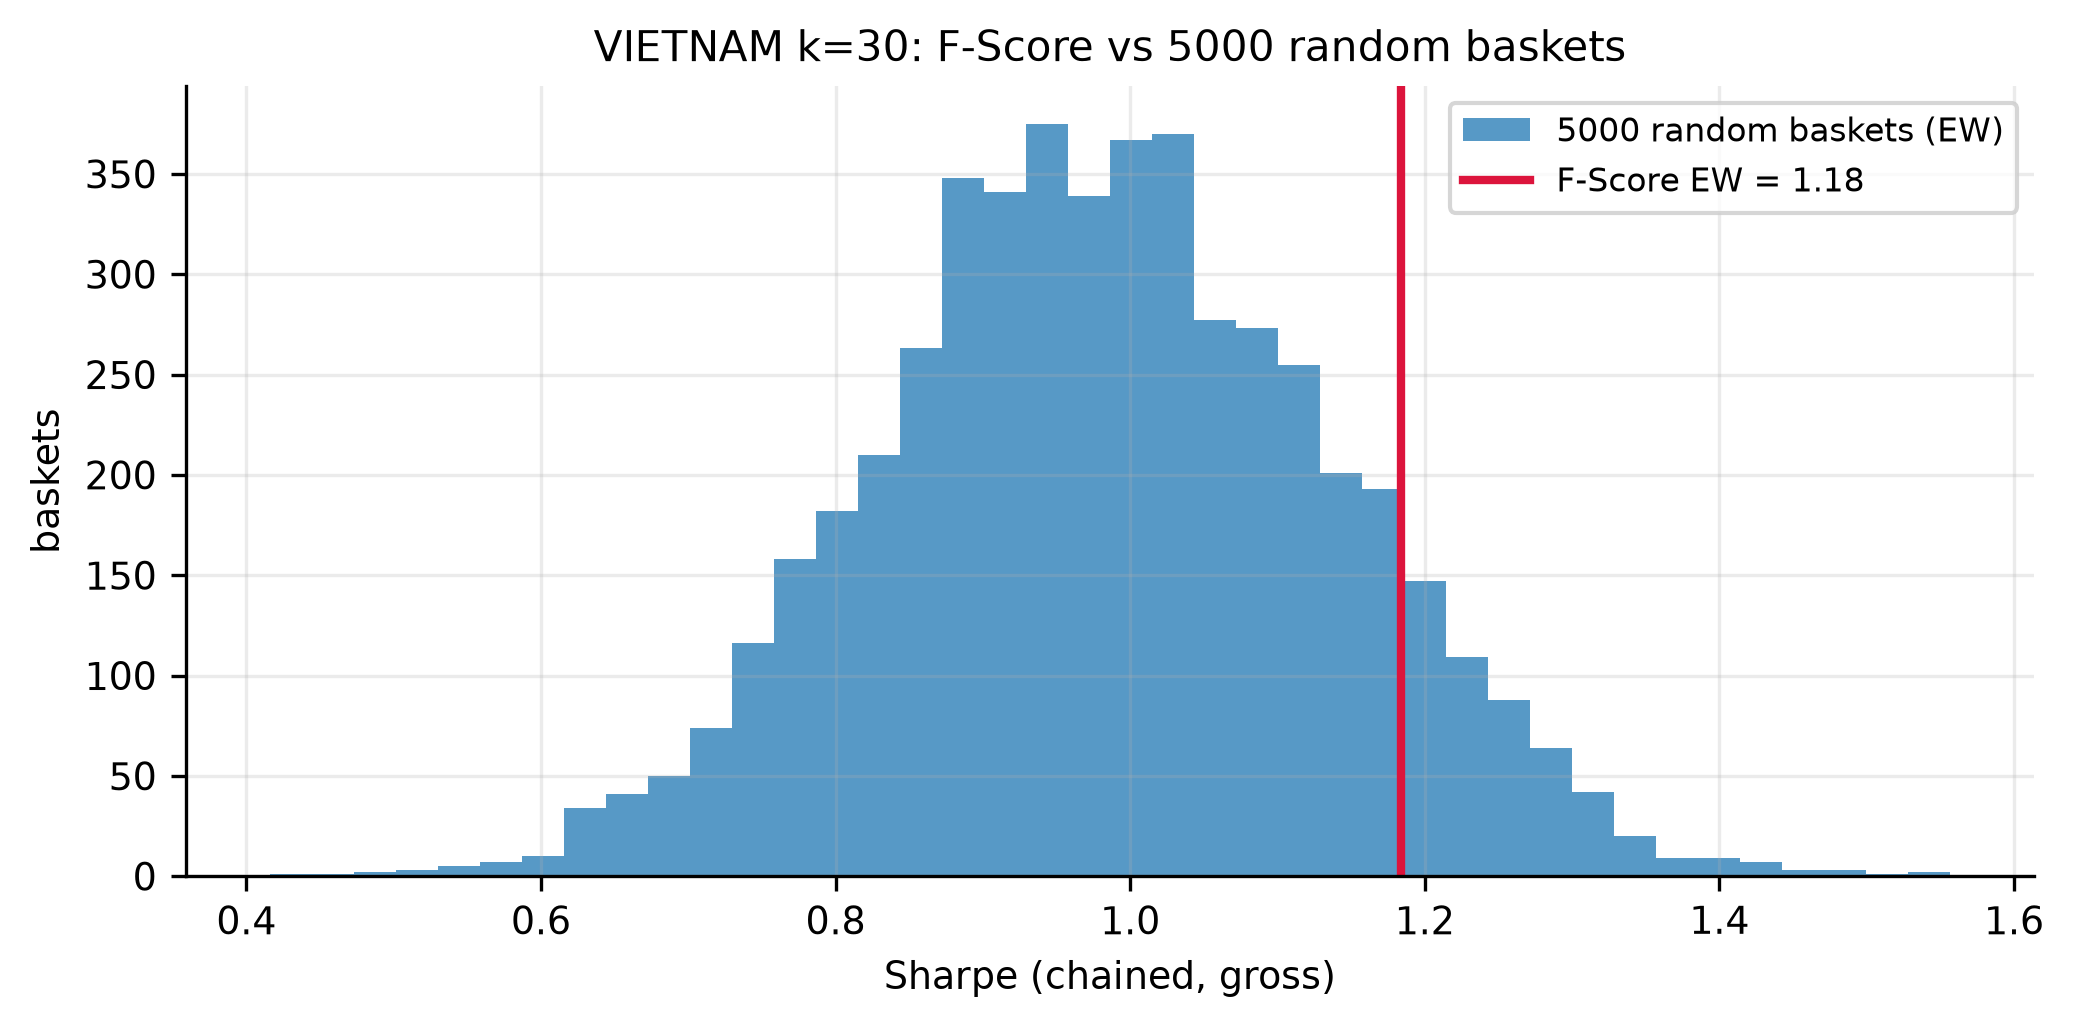

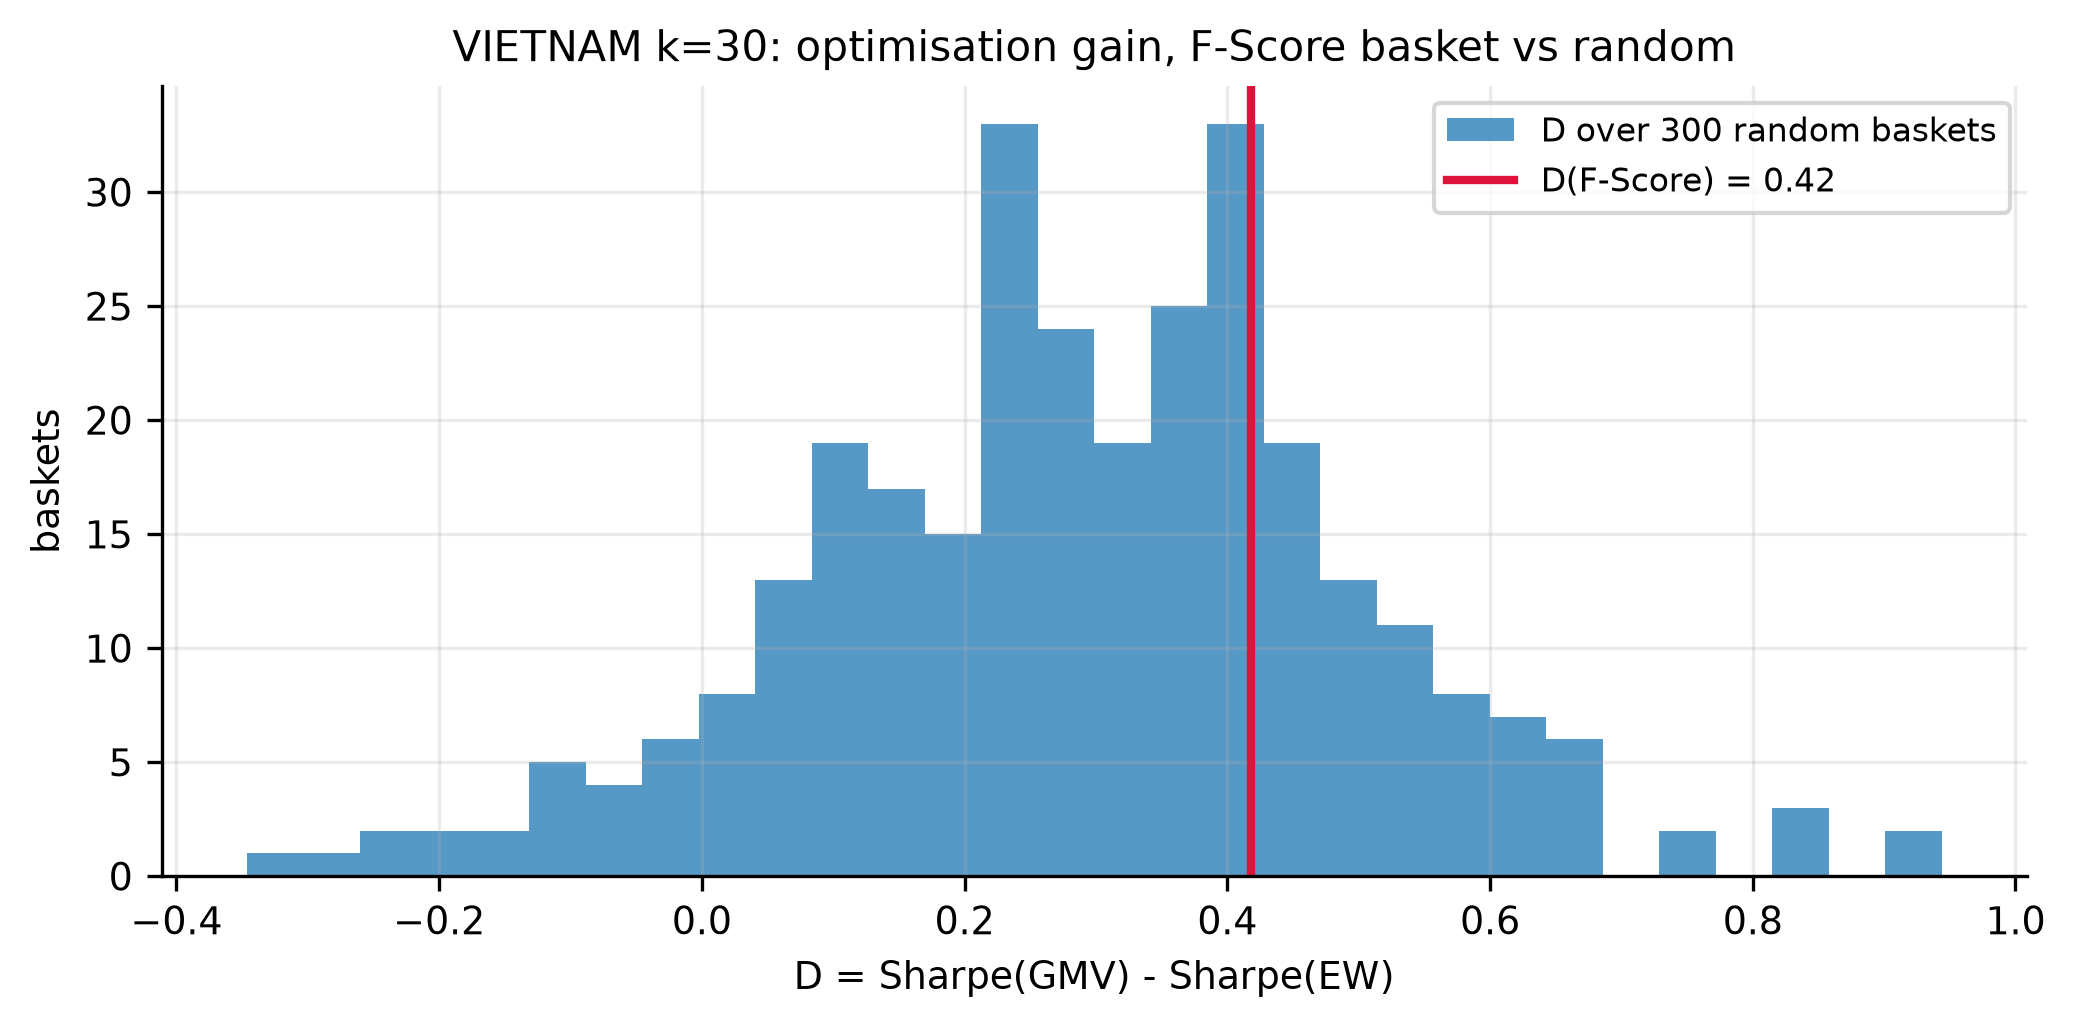

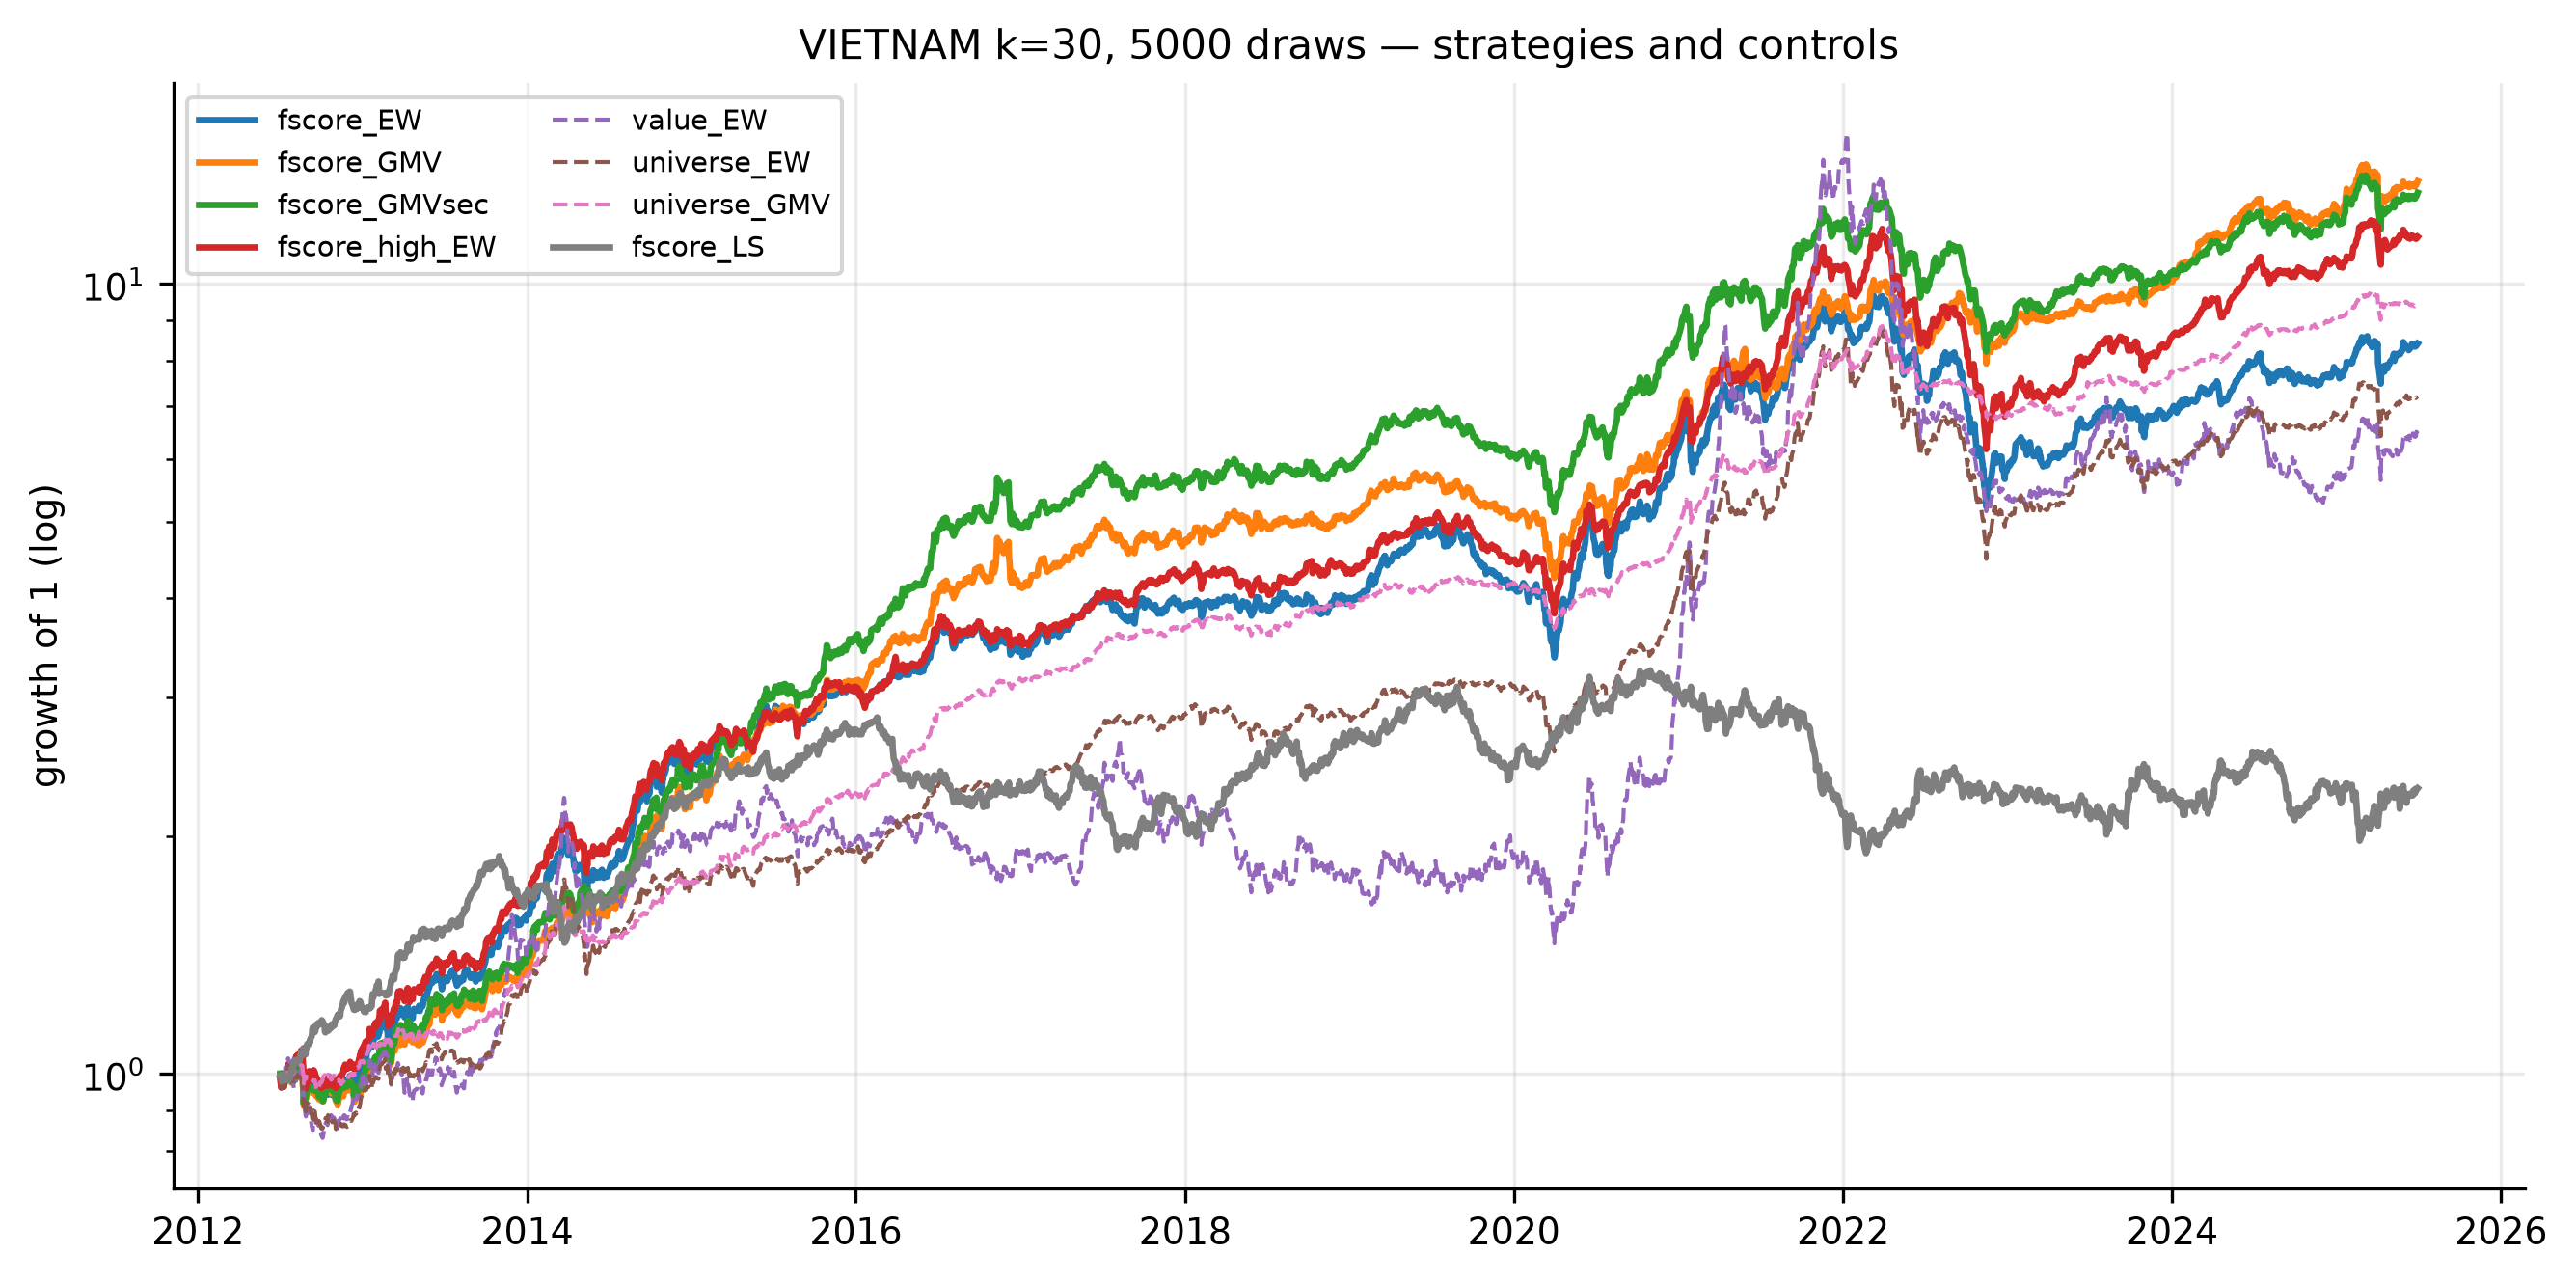

In [10]:
from IPython.display import Image, display
k, n = REF
for suffix in ["mc_hist", "synergy_hist", "nav"]:
    display(Image(filename=str(FIG / f"{MARKET}_k{k}_mc{n}_{suffix}.png"), width=640))

### 4. The consolidated grid

One row per cell. This is what the grid was built to show: whether the
conclusion moves with the basket size or with the number of random draws.

`N` should not move anything but the resolution of the p-value — the same
seed draws the same first 1,000 baskets whether the run asks for 1,000 or
5,000 — so any drift down an `N` block is Monte-Carlo noise, not a finding.
Movement across `k` blocks is the real sensitivity.

In [11]:
rows = []
for (k, n_mc), (st, summ, place, sy, yr, dg) in cells_out.items():
    pl = place.loc[("random (full universe)", "sharpe", "gross")]
    rows.append({
        "mkt": MARKET, "k": k, "N": n_mc,
        "EW": round(float(summ.loc["fscore_EW", "sharpe"]), 4),
        "uniEW": round(float(summ.loc["universe_EW", "sharpe"]), 4)
                 if "universe_EW" in summ.index else np.nan,
        "value": round(float(summ.loc["value_EW", "sharpe"]), 4)
                 if "value_EW" in summ.index else np.nan,
        "to_EW": round(float(summ.loc["fscore_EW", "turnover"]), 4),
        "effN_GMV": round(float(summ.loc["fscore_GMV", "effective_n"]), 4)
                    if "fscore_GMV" in summ.index else np.nan,
        "pct": round(float(pl["percentile"]), 4),
        "p": round(float(pl["p_value"]), 4),
        "sig": bool(pl["significant"]),
        "D": round(float(sy["D_fscore"]), 4),
        "D_p": round(float(sy["p_value"]), 4),
    })
grid = pd.DataFrame(rows).sort_values(["k", "N"]).reset_index(drop=True)
grid.to_csv(OUT / f"{MARKET}_grid_summary.csv", index=False)
grid

,mkt,k,N,EW,uniEW,value,to_EW,effN_GMV,pct,p,sig,D,D_p
0,vietnam,20,1000,1.2856,1.2848,0.5943,0.8958,10.0806,0.9900,0.0100,True,0.2270,0.5000
1,vietnam,20,2000,1.2856,1.2848,0.5943,0.8958,10.0806,0.9860,0.0140,True,0.2270,0.5000
2,vietnam,20,5000,1.2856,1.2848,0.5943,0.8958,10.0806,0.9842,0.0158,True,0.2270,0.5000
3,vietnam,25,1000,1.3179,1.2848,0.6619,0.8951,11.4748,0.9900,0.0100,True,0.4513,0.1400
4,vietnam,25,2000,1.3179,1.2848,0.6619,0.8951,11.4748,0.9865,0.0135,True,0.4513,0.1400
5,vietnam,25,5000,1.3179,1.2848,0.6619,0.8951,11.4748,0.9852,0.0148,True,0.4513,0.1400
6,vietnam,30,1000,1.1837,1.2848,0.6566,0.8943,13.7275,0.8920,0.1080,False,0.4178,0.2533
7,vietnam,30,2000,1.1837,1.2848,0.6566,0.8943,13.7275,0.8905,0.1095,False,0.4178,0.2533
8,vietnam,30,5000,1.1837,1.2848,0.6566,0.8943,13.7275,0.8952,0.1048,False,0.4178,0.2533


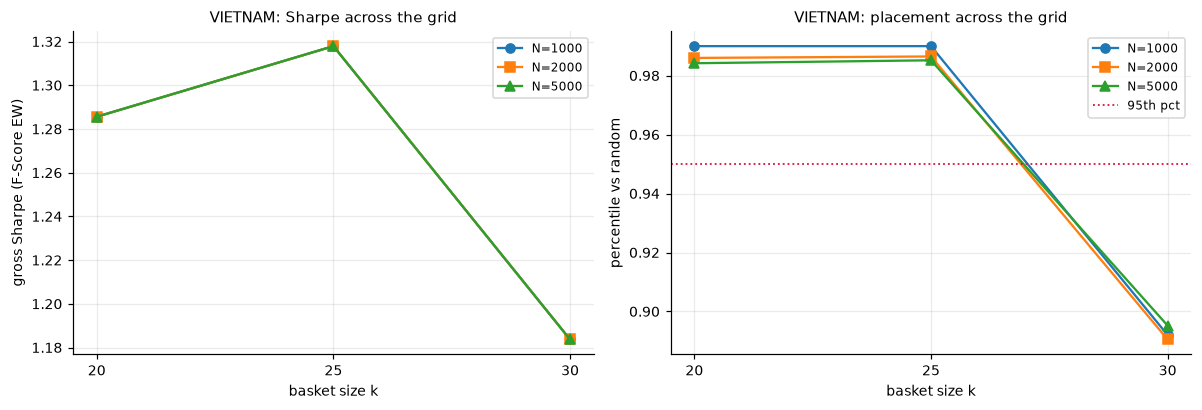

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for n_mc, mark in zip(MCS, ["o", "s", "^"]):
    sub = grid[grid.N == n_mc]
    axes[0].plot(sub.k, sub.EW, mark + "-", label=f"N={n_mc}")
    axes[1].plot(sub.k, sub.pct, mark + "-", label=f"N={n_mc}")
axes[0].set_xlabel("basket size k"); axes[0].set_ylabel("gross Sharpe (F-Score EW)")
axes[0].set_title(f"{MARKET.upper()}: Sharpe across the grid")
axes[1].axhline(0.95, color="crimson", ls=":", lw=1.2, label="95th pct")
axes[1].set_xlabel("basket size k"); axes[1].set_ylabel("percentile vs random")
axes[1].set_title(f"{MARKET.upper()}: placement across the grid")
for a in axes:
    a.set_xticks(KS); a.legend(fontsize=8)
plt.tight_layout(); save_fig(f"{MARKET}_grid_sensitivity", directory=FIG); plt.show()

### 5. Outputs

Each cell's five CSVs and four figures are already on disk under its own
`{market}_k{k}_mc{N}_*` tag — unchanged from when every cell was its own
notebook. This notebook adds one file the eighteen never produced: the
consolidated `{market}_grid_summary.csv` above, which used to be assembled by
hand.

In [13]:
print(f"per-cell outputs : results/grid/{MARKET}_k*_mc*_*.csv  "
      f"({len(cells_out) * 6} files)")
print(f"per-cell figures : results/figures/{MARKET}_k*_mc*_*.png  "
      f"({len(cells_out) * 4} files)")
print(f"consolidated     : results/grid/{MARKET}_grid_summary.csv")

per-cell outputs : results/grid/vietnam_k*_mc*_*.csv  (54 files)
per-cell figures : results/figures/vietnam_k*_mc*_*.png  (36 files)
consolidated     : results/grid/vietnam_grid_summary.csv
